#실습(ViT)

In [1]:
#FashionMNIST 다운로드

from itertools import chain
from collections import defaultdict
from torch.utils.data import Subset
from torchvision import datasets

def subset_sampler(dataset, classes, max_len):
  target_idx = defaultdict(list)
  for idx, label in enumerate(dataset.train_labels):
    target_idx[int(label)].append(idx)

  indices = list(
      chain.from_iterable(
          [target_idx[idx][:max_len] for idx in range(len(classes))]
      )
  )
  return Subset(dataset, indices)

train_dataset = datasets.FashionMNIST(root=".../datasets", download=True, train=True)
test_dataset = datasets.FashionMNIST(root=".../datasets", download=True, train=False)

classes = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

print(classes)
print(class_to_idx)

subset_train_dataset = subset_sampler(
    dataset=train_dataset, classes=train_dataset.classes, max_len=1000
)
subset_test_dataset = subset_sampler(
    dataset=test_dataset, classes=test_dataset.classes, max_len=100
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 185kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.13MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.7MB/s]


['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
{'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}


/usr/local/lib/python3.11/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")


In [2]:
print(f"Train dataset size: {len(subset_train_dataset)}")
print(f"Test dataset size: {len(subset_test_dataset)}")
print(train_dataset[0])

Train dataset size: 10000
Test dataset size: 1000
(<PIL.Image.Image image mode=L size=28x28 at 0x7C98FA1ADC50>, 9)


In [3]:
#이미지 전처리

import torch
from torchvision import transforms
from transformers import AutoImageProcessor

image_processor = AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path="google/vit-base-patch16-224-in21k"
)

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize(
           size=(
               image_processor.size["height"],
               image_processor.size["width"]
           )
        ),
        transforms.Lambda(
            lambda x:torch.cat([x,x,x],0)
        ),
        transforms.Normalize(
            mean=image_processor.image_mean,
            std=image_processor.image_std
        )
    ]
)

print(f"size : {image_processor.size}")
print(f"mean : {image_processor.image_mean}")
print(f"std : {image_processor.image_std}")



/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


size : {'height': 224, 'width': 224}
mean : [0.5, 0.5, 0.5]
std : [0.5, 0.5, 0.5]


In [4]:
#ViT 데이터로더 사용

from torch.utils.data import DataLoader

def collator(data, transform):
  images, labels = zip(*data)
  pixel_values = [transform(image) for image in images]
  pixel_values = torch.stack(pixel_values)  # 리스트 → 텐서
  labels = torch.tensor(labels)
  return {"pixel_values": pixel_values, "labels": labels}

train_dataloader = DataLoader(
    subset_train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=lambda x: collator(x, transform),
    drop_last=True
)
valid_dataloader = DataLoader(
    subset_test_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=lambda x: collator(x, transform),
    drop_last=True
)

batch=next(iter(train_dataloader))
for k,v in batch.items():
  print(f"{k}: {v.shape}")

pixel_values: torch.Size([32, 3, 224, 224])
labels: torch.Size([32])


In [5]:
#사전 학습된 ViT 모델

from transformers import ViTForImageClassification

model = ViTForImageClassification.from_pretrained(
    pretrained_model_name_or_path="google/vit-base-patch16-224-in21k",
    num_labels=len(classes),
    id2label={idx:label for label, idx in class_to_idx.items()},
    label2id=class_to_idx,
    ignore_mismatched_sizes=True
)

print(model.classifier)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Linear(in_features=768, out_features=10, bias=True)


In [6]:
#패치 임베딩 확인

print(model.vit.embeddings)

batch = next(iter(train_dataloader))
print("image shape:", batch["pixel_values"].shape)

outputs = model.vit.embeddings(batch["pixel_values"])
print("embeddings shape:", outputs.shape)

print("[CLS] + patch embeddings shape : ",
      model.vit.embeddings(batch["pixel_values"]).shape
)

ViTEmbeddings(
  (patch_embeddings): ViTPatchEmbeddings(
    (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  )
  (dropout): Dropout(p=0.0, inplace=False)
)
image shape: torch.Size([32, 3, 224, 224])
embeddings shape: torch.Size([32, 197, 768])
[CLS] + patch embeddings shape :  torch.Size([32, 197, 768])


In [7]:
import transformers
print(transformers.TrainingArguments.__module__)
print(transformers.__file__)

from inspect import getfile
from transformers import TrainingArguments
print(getfile(TrainingArguments))

from transformers import TrainingArguments
import inspect

print(inspect.signature(TrainingArguments.__init__))


transformers.training_args
/usr/local/lib/python3.11/dist-packages/transformers/__init__.py
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py
(self, output_dir: Optional[str] = None, overwrite_output_dir: bool = False, do_train: bool = False, do_eval: bool = False, do_predict: bool = False, eval_strategy: Union[transformers.trainer_utils.IntervalStrategy, str] = 'no', prediction_loss_only: bool = False, per_device_train_batch_size: int = 8, per_device_eval_batch_size: int = 8, per_gpu_train_batch_size: Optional[int] = None, per_gpu_eval_batch_size: Optional[int] = None, gradient_accumulation_steps: int = 1, eval_accumulation_steps: Optional[int] = None, eval_delay: Optional[float] = 0, torch_empty_cache_steps: Optional[int] = None, learning_rate: float = 5e-05, weight_decay: float = 0.0, adam_beta1: float = 0.9, adam_beta2: float = 0.999, adam_epsilon: float = 1e-08, max_grad_norm: float = 1.0, num_train_epochs: float = 3.0, max_steps: int = -1, lr_scheduler_type: U

In [8]:
#하이퍼파라미터 설정
args = TrainingArguments(
    output_dir="../models/ViT-FashionMNIST",
    save_strategy="epoch",
    eval_strategy="epoch", #evaluation_strategy 라고 쓰면 오류
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.001,
    load_best_model_at_end=True,
    logging_dir="logs",
    metric_for_best_model="f1",
    logging_steps=125,
    remove_unused_columns=False,
    seed=7
)

In [9]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 21.7 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.

In [10]:
#매크로 평균 F1 점수

import evaluate
import numpy as np

def compute_metrics(eval_pred):
  metric = evaluate.load("f1")
  predictions, labels = eval_pred
  predictions = np.argmax(predictions, axis=1)
  macro_f1 = metric.compute(
      predictions = predictions, references=labels, average="macro"
  )
  return macro_f1

In [11]:
#ViT 모델 학습

import torch
import evaluate
import numpy as np
from itertools import chain
from collections import defaultdict
from torch.utils.data import Subset
from torchvision import datasets
from torchvision import transforms
from transformers import AutoImageProcessor
from transformers import ViTForImageClassification
from transformers import TrainingArguments, Trainer


def subset_sampler(dataset, classes, max_len):
    target_idx = defaultdict(list)
    for idx, label in enumerate(dataset.train_labels):
        target_idx[int(label)].append(idx)

    indices = list(
        chain.from_iterable(
            [target_idx[idx][:max_len] for idx in range(len(classes))]
        )
    )
    return Subset(dataset, indices)


def model_init(classes, class_to_idx):
    model = ViTForImageClassification.from_pretrained(
        pretrained_model_name_or_path="google/vit-base-patch16-224-in21k",
        num_labels=len(classes),
        id2label={idx: label for label, idx in class_to_idx.items()},
        label2id=class_to_idx,
    )
    return model


def collator(data, transform):
    images, labels = zip(*data)
    pixel_values = torch.stack([transform(image) for image in images])
    labels = torch.tensor([label for label in labels])
    return {"pixel_values": pixel_values, "labels": labels}


def compute_metrics(eval_pred):
    metric = evaluate.load("f1")
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    macro_f1 = metric.compute(
        predictions=predictions, references=labels, average="macro"
    )
    return macro_f1


train_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=True)
test_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=False)

classes = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

subset_train_dataset = subset_sampler(
    dataset=train_dataset, classes=train_dataset.classes, max_len=1000
)
subset_test_dataset = subset_sampler(
    dataset=test_dataset, classes=test_dataset.classes, max_len=100
)

image_processor = AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path="google/vit-base-patch16-224-in21k"
)

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize(
            size=(
                image_processor.size["height"],
                image_processor.size["width"]
            )
        ),
        transforms.Lambda(
            lambda x: torch.cat([x, x, x], 0)
        ),
        transforms.Normalize(
            mean=image_processor.image_mean,
            std=image_processor.image_std
        )
    ]
)

args = TrainingArguments(
    output_dir="../models/ViT-FashionMNIST",
    save_strategy="epoch",
    eval_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.001,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="logs",
    logging_steps=125,
    remove_unused_columns=False,
    seed=7,
    report_to=[]
)

trainer = Trainer(
    model_init=lambda x: model_init(classes, class_to_idx),
    args=args,
    train_dataset=subset_train_dataset,
    eval_dataset=subset_test_dataset,
    data_collator=lambda x: collator(x, transform),
    compute_metrics=compute_metrics,
    tokenizer=image_processor,
)

trainer.train()


100%|██████████| 26.4M/26.4M [00:02<00:00, 10.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 171kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.11MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.7MB/s]
/usr/local/lib/python3.11/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
<ipython-input-11-c2af4ab98439>:110: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier

Epoch,Training Loss,Validation Loss,F1
1,0.701200,0.632806,0.887717
2,0.477100,0.474934,0.914266
3,0.417500,0.427622,0.921969


TrainOutput(global_step=1875, training_loss=0.696924599202474, metrics={'train_runtime': 1199.0241, 'train_samples_per_second': 25.02, 'train_steps_per_second': 1.564, 'total_flos': 2.32492637712384e+18, 'train_loss': 0.696924599202474, 'epoch': 3.0})

PredictionOutput(predictions=array([[ 3.0693934 , -0.6419973 , -0.31907424, ..., -0.5753024 ,
        -0.36583692, -0.61208725],
       [ 2.0925777 , -0.6916841 , -0.24224174, ..., -0.82365996,
        -0.8257609 , -0.9833377 ],
       [ 2.9780877 , -0.6176911 , -0.22471532, ..., -0.528934  ,
        -0.3656171 , -0.61164045],
       ...,
       [-0.5713575 , -0.6026215 , -0.57172394, ...,  0.5879124 ,
         0.43982553,  2.9884944 ],
       [-0.561624  , -0.39240003, -0.30723265, ...,  0.1320488 ,
        -0.3004883 ,  3.4011621 ],
       [-0.5191005 , -0.32667384, -0.29866773, ..., -0.2713037 ,
        -0.15728462,  3.4125807 ]], dtype=float32), label_ids=array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

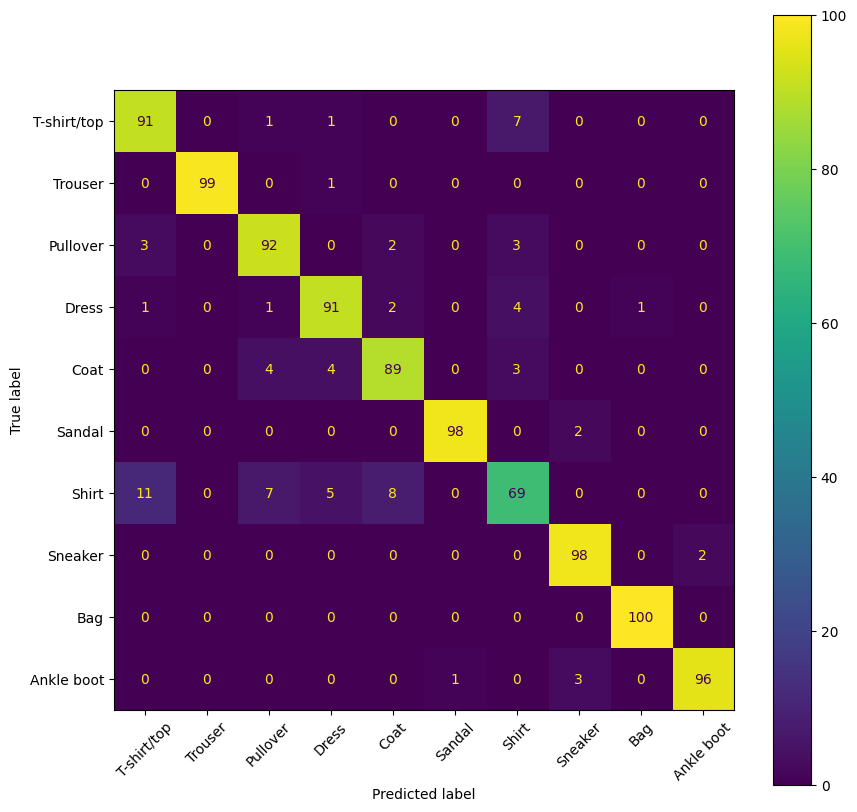

In [12]:
#ViT 모델 성능 평가

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

outputs = trainer.predict(subset_test_dataset)
print(outputs)

y_true = outputs.label_ids
y_pred = outputs.predictions.argmax(1)

labels = list(classes)
matrix = confusion_matrix(y_true, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=labels)

_, ax = plt.subplots(figsize=(10, 10))
display.plot(xticks_rotation=45, ax=ax)
plt.show()


#2. 스윈 트랜스포머

### 상대적 위치 편향

In [17]:
#상대적 위치 편향 계산

import torch

window_size = 2
coords_h = torch.arange(window_size)
coords_w = torch.arange(window_size)
coords = torch.stack(torch.meshgrid([coords_h, coords_w], indexing="ij"))
coords_flatten = torch.flatten(coords,1)
relative_coords = coords_flatten[:,:,None] - coords_flatten[:, None, :]
print(relative_coords)
print(relative_coords.shape)

tensor([[[ 0,  0, -1, -1],
         [ 0,  0, -1, -1],
         [ 1,  1,  0,  0],
         [ 1,  1,  0,  0]],

        [[ 0, -1,  0, -1],
         [ 1,  0,  1,  0],
         [ 0, -1,  0, -1],
         [ 1,  0,  1,  0]]])
torch.Size([2, 4, 4])


In [19]:
#X,Y 축에 대한 위치 행렬

x_coords = relative_coords[0,:,:]
y_coords = relative_coords[1,:,:]

x_coords += window_size - 1
y_coords += window_size -1
x_coords *= window_size - 1

print(f"X축에 대한 위치 행렬 : \n{x_coords}\n")
print(f"Y축에 대한 위치 행렬 : \n{y_coords}\n")

relative_position_index = x_coords + y_coords
print(f"X,Y 축에 대한 위치 행렬 : \n{relative_position_index}\n")


X축에 대한 위치 행렬 : 
tensor([[1, 1, 0, 0],
        [1, 1, 0, 0],
        [2, 2, 1, 1],
        [2, 2, 1, 1]])

Y축에 대한 위치 행렬 : 
tensor([[1, 0, 1, 0],
        [2, 1, 2, 1],
        [1, 0, 1, 0],
        [2, 1, 2, 1]])

X,Y 축에 대한 위치 행렬 : 
tensor([[2, 1, 1, 0],
        [3, 2, 2, 1],
        [3, 2, 2, 1],
        [4, 3, 3, 2]])



In [21]:
#X,Y 축에 대한 상대적 위치 좌표 변환

num_heads=1
relative_position_bias_table = torch.Tensor(
    torch.zeros((2*window_size -1) * (2*window_size -1), num_heads)
)

relative_position_bias = relative_position_bias_table[relative_position_index.view(-1)]
relative_position_bias = relative_position_bias.view(
    window_size * window_size, window_size * window_size, -1
)
print(relative_position_bias.shape)

torch.Size([4, 4, 1])


In [22]:
#사전 학습된 스윈 트랜스포머 모델

from transformers import SwinForImageClassification

model = SwinForImageClassification.from_pretrained(
    pretrained_model_name_or_path="microsoft/swin-tiny-patch4-window7-224",
    num_labels=len(train_dataset.classes),
    id2label={idx: label for label, idx in train_dataset.class_to_idx.items()},
    label2id=train_dataset.class_to_idx,
    ignore_mismatched_sizes=True
)

for main_name, main_module in model.named_children():
    print(main_name)
    for sub_name, sub_module in main_module.named_children():
        print("└─", sub_name)
        for ssub_name, ssub_module in sub_module.named_children():
            print("   └─", ssub_name)
            for sssub_name, sssub_module in ssub_module.named_children():
                if sssub_name == "projection":
                    print("      └─", sssub_name, sssub_module)
                else:
                    print("      └─", sssub_name)


config.json:   0%|          | 0.00/71.8k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


swin
└─ embeddings
   └─ patch_embeddings
      └─ projection Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
   └─ norm
   └─ dropout
└─ encoder
   └─ layers
      └─ 0
      └─ 1
      └─ 2
      └─ 3
└─ layernorm
└─ pooler
classifier


In [23]:
#패치 임베딩 모듈

batch = next(iter(train_dataloader))
print("이미지 차원:", batch["pixel_values"].shape)

patch_emb_output, shape = model.swin.embeddings.patch_embeddings(batch["pixel_values"])
print("모듈:", model.swin.embeddings.patch_embeddings)
print("패치 임베딩 차원:", patch_emb_output.shape)

이미지 차원: torch.Size([32, 3, 224, 224])
모듈: SwinPatchEmbeddings(
  (projection): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
)
패치 임베딩 차원: torch.Size([32, 3136, 96])


In [24]:
#스윈 트랜스포머 블록

for main_name, main_module in model.swin.encoder.layers[0].named_children():
  print(main_name)
  for sub_name, sub_moduel in main_module.named_children():
    print("L", sub_name)
    for ssub_name, ssub_module in sub_module.named_children():
      print("   L", ssub_name)


blocks
L 0
L 1
downsample
L reduction
L norm


In [25]:
print(model.swin.encoder.layers[0].blocks[0])

SwinLayer(
  (layernorm_before): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  (attention): SwinAttention(
    (self): SwinSelfAttention(
      (query): Linear(in_features=96, out_features=96, bias=True)
      (key): Linear(in_features=96, out_features=96, bias=True)
      (value): Linear(in_features=96, out_features=96, bias=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (output): SwinSelfOutput(
      (dense): Linear(in_features=96, out_features=96, bias=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
  )
  (drop_path): Identity()
  (layernorm_after): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  (intermediate): SwinIntermediate(
    (dense): Linear(in_features=96, out_features=384, bias=True)
    (intermediate_act_fn): GELUActivation()
  )
  (output): SwinOutput(
    (dense): Linear(in_features=384, out_features=96, bias=True)
    (dropout): Dropout(p=0.0, inplace=False)
  )
)


In [26]:
#W-MSA, SW-MSA 모듈

print("패치 임베딩 차원 :", patch_emb_output.shape)

W_MSA = model.swin.encoder.layers[0].blocks[0]
SW_MSA = model.swin.encoder.layers[0].blocks[1]

W_MSA_output = W_MSA(patch_emb_output, W_MSA.input_resolution)[0]
SW_MSA_output = SW_MSA(W_MSA_output, SW_MSA.input_resolution)[0]

print("W-MSA 결과 차원 :", W_MSA_output.shape)
print("SW-MSA 결과 차원 :", SW_MSA_output.shape)


패치 임베딩 차원 : torch.Size([32, 3136, 96])
W-MSA 결과 차원 : torch.Size([32, 3136, 96])
SW-MSA 결과 차원 : torch.Size([32, 3136, 96])


In [27]:
#패치 병합
patch_merge = model.swin.encoder.layers[0].downsample
print("patch_merge 모듈 :", patch_merge)

output = patch_merge(SW_MSA_output, patch_merge.input_resolution)
print("patch_merge 결과 차원 :", output.shape)


patch_merge 모듈 : SwinPatchMerging(
  (reduction): Linear(in_features=384, out_features=192, bias=False)
  (norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
)
patch_merge 결과 차원 : torch.Size([32, 784, 192])


In [30]:
#스윈 트랜스포머 모델 학습

import torch
import evaluate
import numpy as np
from itertools import chain
from collections import defaultdict

from torch.utils.data import Subset
from torchvision import datasets, transforms

from transformers import (
    AutoImageProcessor,
    SwinForImageClassification,
    TrainingArguments,
    Trainer
)

train_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=True)
test_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=False)

classes = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

def subset_sampler(dataset, classes, max_len):
    target_idx = defaultdict(list)
    for idx, label in enumerate(dataset.targets):  # train_labels → targets로 수정
        target_idx[int(label)].append(idx)
    indices = list(chain.from_iterable([target_idx[i][:max_len] for i in range(len(classes))]))
    return Subset(dataset, indices)

subset_train_dataset = subset_sampler(train_dataset, classes, max_len=1000)
subset_test_dataset = subset_sampler(test_dataset, classes, max_len=100)

def model_init(classes, class_to_idx):
    model = SwinForImageClassification.from_pretrained(
        pretrained_model_name_or_path="microsoft/swin-tiny-patch4-window7-224",
        num_labels=len(classes),
        id2label={idx: label for label, idx in class_to_idx.items()},
        label2id=class_to_idx,
        ignore_mismatched_sizes=True
    )
    return model

image_processor = AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path="microsoft/swin-tiny-patch4-window7-224"
)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((image_processor.size["height"], image_processor.size["width"])),
    transforms.Lambda(lambda x: torch.cat([x, x, x], 0)),  # 1채널 → 3채널
    transforms.Normalize(mean=image_processor.image_mean, std=image_processor.image_std),
])

def collator(data, transform):
    images, labels = zip(*data)
    pixel_values = torch.stack([transform(image) for image in images])
    labels = torch.tensor([label for label in labels])
    return {"pixel_values": pixel_values, "labels": labels}

def compute_metrics(eval_pred):
    metric = evaluate.load("f1")
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return metric.compute(predictions=predictions, references=labels, average="macro")

args = TrainingArguments(
    output_dir="../models/Swin-FashionMNIST",
    save_strategy="epoch",
    eval_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.001,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="logs",
    logging_steps=125,
    remove_unused_columns=False,
    seed=7,
    report_to=[]
)

trainer = Trainer(
    model_init=lambda: model_init(classes, class_to_idx),
    args=args,
    train_dataset=subset_train_dataset,
    eval_dataset=subset_test_dataset,
    data_collator=lambda x: collator(x, transform),
    compute_metrics=compute_metrics,
    tokenizer=image_processor
)

trainer.train()


<ipython-input-30-7d25fd873e51>:86: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and 

Epoch,Training Loss,Validation Loss,F1
1,0.346800,0.300104,0.897595
2,0.250200,0.254696,0.910317
3,0.221400,0.225194,0.929172


TrainOutput(global_step=1875, training_loss=0.36511526692708335, metrics={'train_runtime': 483.3393, 'train_samples_per_second': 62.068, 'train_steps_per_second': 3.879, 'total_flos': 7.4584635826176e+17, 'train_loss': 0.36511526692708335, 'epoch': 3.0})

PredictionOutput(predictions=array([[ 8.505391  , -3.0032053 ,  0.03509587, ..., -2.2003534 ,
        -1.9312421 , -2.1007025 ],
       [ 4.4490614 , -0.6198639 ,  0.7354191 , ..., -2.1770139 ,
        -0.9337879 , -3.3366158 ],
       [ 7.696079  , -3.1598887 , -0.48409626, ..., -1.2607266 ,
         0.27859187, -1.7426113 ],
       ...,
       [-1.1045102 , -2.9694402 , -2.1519477 , ...,  1.522443  ,
         0.7042531 ,  4.0296106 ],
       [-0.46593457, -3.2494168 , -1.7045192 , ...,  1.4952279 ,
        -2.803036  ,  8.963177  ],
       [-1.4033711 , -1.892586  , -1.4110471 , ..., -1.2831633 ,
        -2.0076573 ,  8.3612585 ]], dtype=float32), label_ids=array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

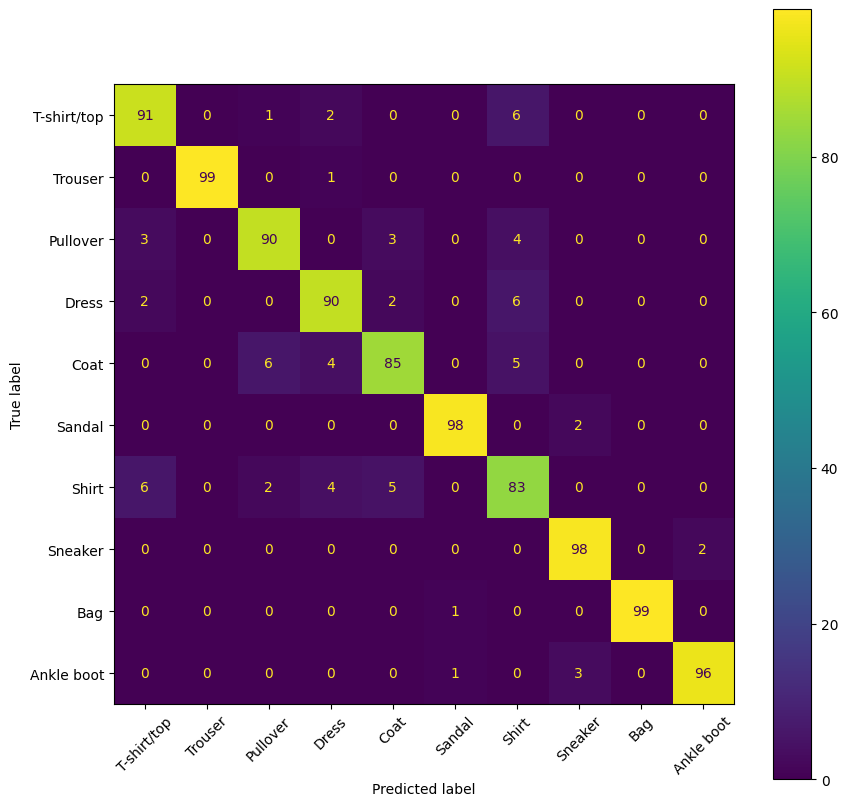

In [31]:
#스윈 모델 성능 평가

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

outputs = trainer.predict(subset_test_dataset)
print(outputs)

y_true = outputs.label_ids
y_pred = outputs.predictions.argmax(1)

labels = list(classes)
matrix = confusion_matrix(y_true, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=labels)

_, ax = plt.subplots(figsize=(10, 10))
display.plot(xticks_rotation=45, ax=ax)
plt.show()

#CvT

In [2]:
#CvT 모델 이미지 데이터 전철

import torch
from torch.utils.data import Subset, DataLoader
from torchvision import datasets, transforms
from transformers import AutoImageProcessor
from itertools import chain
from collections import defaultdict

# 데이터셋 다운로드
train_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=True)
test_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=False)

classes = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

# 클래스 균형 유지한 서브셋 샘플링 함수
def subset_sampler(dataset, classes, max_len):
    target_idx = defaultdict(list)
    for idx, label in enumerate(dataset.train_labels):
        target_idx[int(label)].append(idx)
    indices = list(
        chain.from_iterable([target_idx[idx][:max_len] for idx in range(len(classes))])
    )
    return Subset(dataset, indices)

# 서브셋 생성
subset_train_dataset = subset_sampler(train_dataset, train_dataset.classes, max_len=1000)
subset_test_dataset = subset_sampler(test_dataset, test_dataset.classes, max_len=100)

# CvT 전처리기
image_processor = AutoImageProcessor.from_pretrained("microsoft/cvt-21")

# 이미지 변환
resize_size = image_processor.size if isinstance(image_processor.size, int) else image_processor.size["shortest_edge"]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((resize_size, resize_size)),
    transforms.Lambda(lambda x: torch.cat([x, x, x], 0)),
    transforms.Normalize(
        mean=image_processor.image_mean,
        std=image_processor.image_std
    )
])


# 전처리 적용 collator 함수
def collator(data, transform):
    images, labels = zip(*data)
    pixel_values = torch.stack([transform(image) for image in images])
    labels = torch.tensor(labels)
    return {"pixel_values": pixel_values, "labels": labels}

# DataLoader 정의
train_dataloader = DataLoader(
    subset_train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=lambda x: collator(x, transform),
    drop_last=True
)

test_dataloader = DataLoader(
    subset_test_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=lambda x: collator(x, transform),
    drop_last=False
)



100%|██████████| 26.4M/26.4M [00:02<00:00, 13.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.91MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.7MB/s]
/usr/local/lib/python3.11/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [3]:
#사전 학습된 CvT 모델

from transformers import CvtForImageClassification

model = CvtForImageClassification.from_pretrained(
    pretrained_model_name_or_path="microsoft/cvt-21",
    num_labels=len(train_dataset.classes),
    id2label={idx: label for label, idx in train_dataset.class_to_idx.items()},
    label2id=train_dataset.class_to_idx,
    ignore_mismatched_sizes=True
)

for main_name, main_module in model.named_children():
    print(main_name)
    for sub_name, sub_module in main_module.named_children():
        print("│  ", sub_name)
        for ssub_name, ssub_module in sub_module.named_children():
            print("│   └", ssub_name)
            for sssub_name, sssub_module in ssub_module.named_children():
                print("│     └", sssub_name)


config.json:   0%|          | 0.00/70.3k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/127M [00:00<?, ?B/s]

Some weights of CvtForImageClassification were not initialized from the model checkpoint at microsoft/cvt-21 and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 384]) in the checkpoint and torch.Size([10, 384]) in the model instantiated
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


cvt
│   encoder
│   └ stages
│     └ 0
│     └ 1
│     └ 2
layernorm
classifier


In [4]:
#CvT 모델의 스테이지 구조

stages = model.cvt.encoder.stages
print(stages[0])


CvtStage(
  (embedding): CvtEmbeddings(
    (convolution_embeddings): CvtConvEmbeddings(
      (projection): Conv2d(3, 64, kernel_size=(7, 7), stride=(4, 4), padding=(2, 2))
      (normalization): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (layers): Sequential(
    (0): CvtLayer(
      (attention): CvtAttention(
        (attention): CvtSelfAttention(
          (convolution_projection_query): CvtSelfAttentionProjection(
            (convolution_projection): CvtSelfAttentionConvProjection(
              (convolution): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
              (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            )
            (linear_projection): CvtSelfAttentionLinearProjection()
          )
          (convolution_projection_key): CvtSelfAttentionProjection(
            (convolution_projection): CvtSelfAtte

In [5]:
#셀프 어텐션 적용

batch = next(iter(train_dataloader))
print(batch["pixel_values"].shape)

patch_emb_output = stages[0].embedding(batch["pixel_values"])
print(patch_emb_output.shape)

batch_size, num_channels, height, width = patch_emb_output.shape
hidden_state = patch_emb_output.view(batch_size, num_channels, height * width).permute(0, 2, 1)

print(hidden_state.shape)

attention_output = stages[0].layers[0].attention.attention(hidden_state, height, width)
print(attention_output.shape)


torch.Size([32, 3, 224, 224])
torch.Size([32, 64, 56, 56])
torch.Size([32, 3136, 64])
torch.Size([32, 3136, 64])


In [8]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 18.3 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.

In [9]:
#CvT 모델 학습

import torch
import numpy as np
from collections import defaultdict
from itertools import chain

from torchvision import datasets, transforms
from torch.utils.data import Subset

from transformers import AutoImageProcessor, CvtForImageClassification
from transformers import TrainingArguments, Trainer
import evaluate

def subset_sampler(dataset, classes, max_len):
    target_idx = defaultdict(list)
    for idx, label in enumerate(dataset.targets):
        target_idx[int(label)].append(idx)
    indices = list(
        chain.from_iterable(
            [target_idx[idx][:max_len] for idx in range(len(classes))]
        )
    )
    return Subset(dataset, indices)

def model_init(classes, class_to_idx):
    model = CvtForImageClassification.from_pretrained(
        pretrained_model_name_or_path="microsoft/cvt-21",
        num_labels=len(classes),
        id2label={idx: label for label, idx in class_to_idx.items()},
        label2id=class_to_idx,
        ignore_mismatched_sizes=True
    )
    return model

def collator(data, transform):
    images, labels = zip(*data)
    pixel_values = torch.stack([transform(image) for image in images])
    labels = torch.tensor([label for label in labels])
    return {"pixel_values": pixel_values, "labels": labels}

def compute_metrics(eval_pred):
    metric = evaluate.load("f1")
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    macro_f1 = metric.compute(predictions=predictions, references=labels, average="macro")
    return macro_f1

train_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=True)
test_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=False)

classes = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

subset_train_dataset = subset_sampler(train_dataset, classes, max_len=1000)
subset_test_dataset = subset_sampler(test_dataset, classes, max_len=100)

image_processor = AutoImageProcessor.from_pretrained("microsoft/cvt-21")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(size=(
        image_processor.size["shortest_edge"],
        image_processor.size["shortest_edge"]
    )),
    transforms.Lambda(lambda x: torch.cat([x, x, x], 0)),
    transforms.Normalize(mean=image_processor.image_mean, std=image_processor.image_std)
])

args = TrainingArguments(
    output_dir="../models/CvT-FashionMNIST",
    save_strategy="epoch",
    eval_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.001,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="logs",
    logging_steps=125,
    remove_unused_columns=False,
    seed=7,
    report_to=[]
)

trainer = Trainer(
    model_init=lambda: model_init(classes, class_to_idx),
    args=args,
    train_dataset=subset_train_dataset,
    eval_dataset=subset_test_dataset,
    data_collator=lambda x: collator(x, transform),
    compute_metrics=compute_metrics,
    tokenizer=image_processor
)

trainer.train()


<ipython-input-9-2779540d77d3>:88: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
Some weights of CvtForImageClassification were not initialized from the model checkpoint at microsoft/cvt-21 and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 384]) in the checkpoint and torch.Size([10, 384]) in the model instantiated
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of CvtForImageClassification were not initialized from the model checkpoint at microsoft/cvt-21 and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 384]) in the checkpoint and torch.Size([10, 384]) in the model insta

Epoch,Training Loss,Validation Loss,F1
1,0.805000,0.329982,0.886639
2,0.684400,0.275579,0.907541
3,0.669700,0.265388,0.911864


TrainOutput(global_step=1875, training_loss=0.7928322102864583, metrics={'train_runtime': 720.7678, 'train_samples_per_second': 41.622, 'train_steps_per_second': 2.601, 'total_flos': 8.4649093853184e+17, 'train_loss': 0.7928322102864583, 'epoch': 3.0})

PredictionOutput(predictions=array([[ 6.8337607 , -1.4081361 ,  0.4163791 , ..., -1.3762286 ,
        -0.2877056 , -1.7838625 ],
       [ 3.5465963 , -0.40339392, -0.3964268 , ..., -2.119947  ,
        -1.2050375 , -2.2624907 ],
       [ 7.1485367 , -1.5595388 ,  0.15012799, ..., -0.9187974 ,
        -0.35331008, -1.3368659 ],
       ...,
       [-1.1460027 , -1.3758284 , -1.0077322 , ...,  2.0430257 ,
        -0.22816093,  4.7874722 ],
       [-0.99802536, -0.6723007 , -0.52242666, ...,  0.94801605,
        -0.96851456,  7.0190554 ],
       [-1.7805254 , -0.04965935, -0.684834  , ..., -0.4873112 ,
        -0.39893967,  6.956288  ]], dtype=float32), label_ids=array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

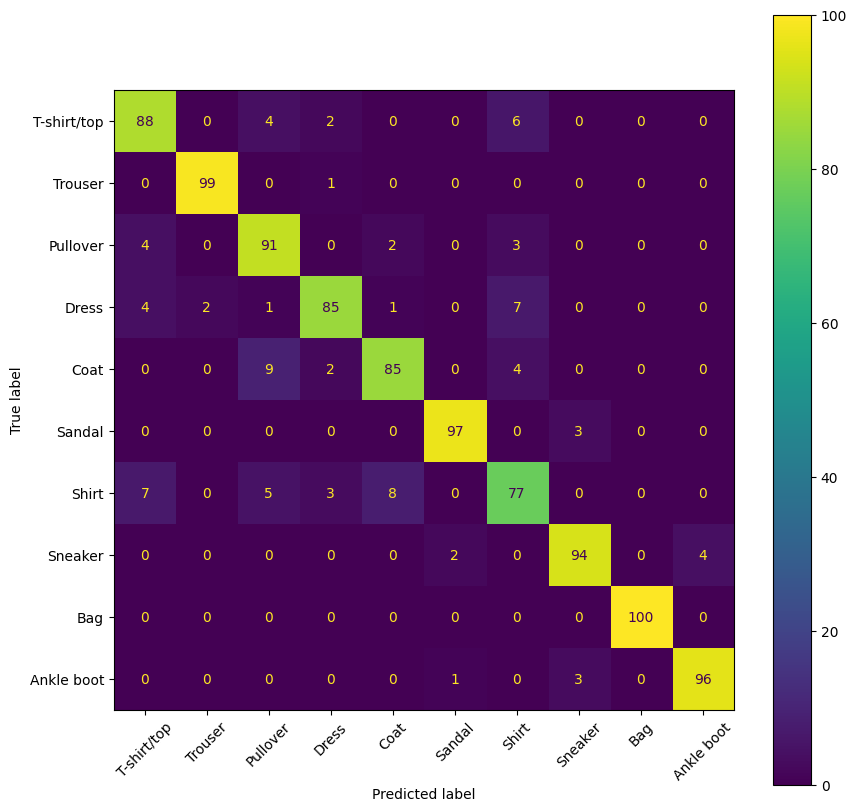

In [10]:
#CvT 모델 성능 평가

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

outputs = trainer.predict(subset_test_dataset)
print(outputs)

y_true = outputs.label_ids
y_pred = outputs.predictions.argmax(1)

labels = list(classes)
matrix = confusion_matrix(y_true, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=labels)

_, ax = plt.subplots(figsize=(10, 10))
display.plot(xticks_rotation=45, ax=ax)
plt.show()